In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px


In [53]:
url = "games.csv"
juegos = pd.read_csv(url)

Eliminar= Unnamed 0, , summary, backlogs, wishlist
Rename =plays, jugadorestotal, playing, jugadoresactuales

In [55]:

juegos.drop(columns=["Unnamed: 0", "Summary", "Backlogs","Wishlist"], inplace=True)

In [56]:
juegos.drop(columns=["Reviews"], inplace=True)

In [57]:
juegos.rename(columns={"Title":"titulo", "Release Date":"fecha_de_lanzamiento", "Team":"equipo", "Rating":"calificacion","Times Listed":"veces_mencionadas","Number of Reviews":"numero_de_resenas","Genres":"generos","Plays":"jugadores_totales","Playing":"jugadores_activos"}, inplace=True)

In [ ]:
juegos.loc[juegos['titulo'] == "Hades"]

In [ ]:
juegos_duplicados = juegos.duplicated()
print(juegos[juegos_duplicados])

In [61]:
juegos.drop_duplicates(inplace=True)

In [62]:
juegos.isnull().sum()

titulo                   0
fecha_de_lanzamiento     0
equipo                   1
calificacion            13
veces_mencionadas        0
numero_de_resenas        0
generos                  0
jugadores_totales        0
jugadores_activos        0
dtype: int64

In [ ]:
juegos.loc[juegos['equipo'].isnull()]

In [ ]:
juegos.fillna(columns="equipo", value="Hitsuji", inplace=True)

C:\Users\twoem\AppData\Local\Temp\ipykernel_3408\2762928740.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  juegos['equipo'].fillna("Hitsuji", inplace=True)


In [ ]:
juegos.loc[juegos["calificacion"].isnull()] 

In [66]:
juegos.dropna(subset=["calificacion"], inplace=True)

In [67]:
juegos.loc[juegos['titulo']== 'Jun']

,titulo,fecha_de_lanzamiento,equipo,calificacion,veces_mencionadas,numero_de_resenas,generos,jugadores_totales,jugadores_activos


In [ ]:
juegos.loc[juegos['fecha_de_lanzamiento'] == "releases on TBD"]

In [70]:
deltarune= juegos['titulo']== 'Deltarune'
juegos.loc[deltarune, 'fecha_de_lanzamiento'] = juegos.loc[deltarune,'fecha_de_lanzamiento'].str.replace("releases on TBD","Jun 04, 2025")

In [71]:
elden = juegos['titulo']== 'Elden Ring: Shadow of the Erdtree'
juegos.loc[elden, 'fecha_de_lanzamiento'] = juegos.loc[elden,'fecha_de_lanzamiento'].str.replace("releases on TBD","Jun 20, 2024")
#juegos = juegos.loc[juegos['titulo'] == 'Elden Ring: Shadow of the Erdtree'].replace("releases on TBD","Jun 20,2024")

In [72]:
juegos['fecha_de_lanzamiento']= pd.to_datetime(juegos['fecha_de_lanzamiento'])

In [ ]:
juegos["calificacion"].head(20)

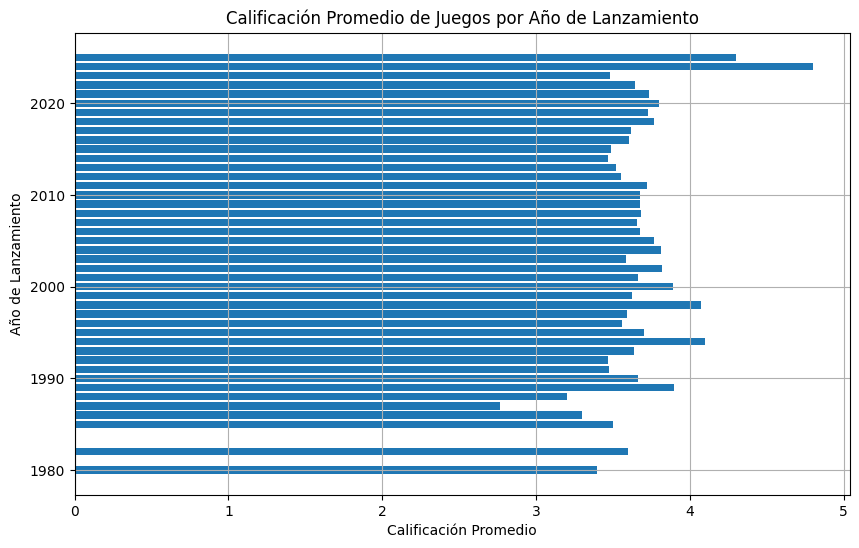

In [ ]:
ano_lanzamiento = juegos['fecha_de_lanzamiento'].dt.year
#juegos.groupby(ano_lanzamiento)['calificacion'].count().sort_values(ascending=False).head(20)
calificacion_juegos_por_ano = juegos.pivot_table(index=ano_lanzamiento, values="calificacion", aggfunc='mean').sort_values(by="calificacion")
plt.figure(figsize=(10,6))
plt.barh(calificacion_juegos_por_ano['calificacion'], calificacion_juegos_por_ano.index)
plt.title('Calificación Promedio de Juegos por Año de Lanzamiento')
plt.xlabel('Calificación Promedio')
plt.ylabel('Año de Lanzamiento')
plt.grid()

In [94]:
juegos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1106 entries, 0 to 1511
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   titulo                1106 non-null   object        
 1   fecha_de_lanzamiento  1106 non-null   datetime64[ns]
 2   equipo                1106 non-null   object        
 3   calificacion          1106 non-null   float64       
 4   veces_mencionadas     1106 non-null   int64         
 5   numero_de_resenas     1106 non-null   int64         
 6   generos               1106 non-null   object        
 7   jugadores_totales     1106 non-null   int64         
 8   jugadores_activos     1106 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(4), object(3)
memory usage: 86.4+ KB


In [93]:
juegos['veces_mencionadas'] = juegos['veces_mencionadas'].str.replace("K","", regex=False).astype(float)*1000
juegos['veces_mencionadas'] = juegos['veces_mencionadas'].astype(int)

In [88]:
juegos['numero_de_resenas']= juegos['numero_de_resenas'].str.replace("K","", regex=False).astype(float)*1000

In [90]:
juegos['numero_de_resenas'] = juegos['numero_de_resenas'].astype(int)

In [82]:
juegos['jugadores_totales'] = juegos['jugadores_totales'].str.replace("K","", regex=False).astype(float)*1000
juegos['jugadores_activos'] = juegos['jugadores_activos'].str.replace("K","", regex=False).astype(float)*1000

In [84]:
juegos['jugadores_totales'] = juegos['jugadores_totales'].astype(int)
juegos['jugadores_activos'] = juegos['jugadores_activos'].astype(int)

In [101]:
juegos['generos'].head(20)

0                                  ['Adventure', 'RPG']
1              ['Adventure', 'Brawler', 'Indie', 'RPG']
2                                  ['Adventure', 'RPG']
3     ['Adventure', 'Indie', 'RPG', 'Turn Based Stra...
4                    ['Adventure', 'Indie', 'Platform']
5                            ['Adventure', 'Simulator']
6     ['Adventure', 'Indie', 'RPG', 'Turn Based Stra...
7                             ['Adventure', 'Platform']
8                                 ['Indie', 'Strategy']
9                                    ['Brawler', 'RPG']
10          ['Adventure', 'RPG', 'Turn Based Strategy']
11                               ['Adventure', 'Indie']
12                      ['Adventure', 'Brawler', 'RPG']
13       ['Adventure', 'Platform', 'Puzzle', 'Shooter']
14                                 ['Adventure', 'RPG']
15                   ['Adventure', 'Indie', 'Platform']
16         ['Adventure', 'Brawler', 'RPG', 'Simulator']
17                      ['Adventure', 'RPG', 'Sh